In [18]:
import importlib
import pandas as pd
import numpy as np
import re
from pathlib import Path

import functions
importlib.reload(functions)
from functions import *

df_1111 = pd.read_csv("AI_Lit_Que_1111.csv")
df_1204 = pd.read_csv("AI_Lit_Que_1204.csv")

# add source/course label
df_1111["course"] = "1111"
df_1204["course"] = "1204"

print(df_1111.shape, df_1204.shape)


(118, 37) (23, 37)


-----
# EDA
## Descriptive statistics

### Mean comparison

#### SES

- Class 1111 is very slightly below the pooled SES average
- Class 1204 is slightly above the pooled SES average

The difference is present but not large in raw standardized units.

- *Skew < 0*: SES is somewhat left-skewed, especially in 1204.
  More observations are clustered on the higher side,
  with a tail toward lower SES-index values.

#### AI Literacy

- Class 1204 appears to have higher AI literacy on average than class 1111.
  The gap here is much more visible than for SES.


In [2]:
df, meta = prepare_dataset("AI_Lit_Que_1111.csv", "AI_Lit_Que_1204.csv")

# prepare_dataset is a preprocessing function defined in functions.py
construct_summary_table(df)

,sample,construct,n,mean,sd,median,iqr,skew
0,1111,SES index,118,-2.184274e-02,0.570420,0.003448,0.792470,-0.409507
1,1111,AI literacy score,118,3.490678e+00,0.409291,3.500000,0.500000,0.266702
2,1204,SES index,23,1.120627e-01,0.569433,0.235097,0.661270,-0.804122
3,1204,AI literacy score,23,3.800000e+00,0.450252,3.900000,0.750000,0.134169
4,Combined,SES index,141,-2.834612e-17,0.570388,0.020992,0.801864,-0.460321
5,Combined,AI literacy score,141,3.541135e+00,0.430128,3.500000,0.600000,0.294079


### Measurement consistency

#### SES

- SES shows **moderate** consistency across both classes
  (pooled Cronbach's α = 0.69).

#### AI Literacy

- AI literacy shows **low** consistency across both classes
  (pooled Cronbach's α = 0.52; even lower in 1111).

The AI literacy items do not appear to function as a highly homogeneous
single scale in this sample.


In [35]:
reliability_table(df, meta)

,sample,construct,alpha,n_complete
0,1111,SES index ingredients,0.689986,118
1,1111,AI literacy score,0.466021,118
2,1204,SES index ingredients,0.739366,23
3,1204,AI literacy score,0.624770,23
4,Combined,SES index ingredients,0.693905,141
5,Combined,AI literacy score,0.523376,141


### Effect sizes: Two-sided Mann–Whitney U test

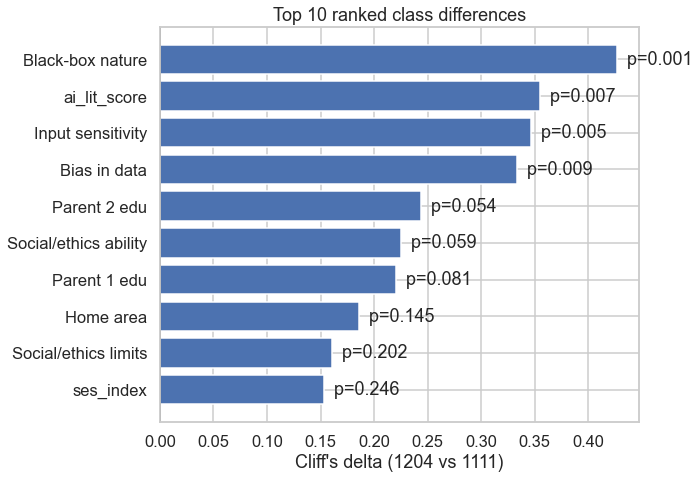

In [36]:
eff = effect_size_table(df, meta)
plot_ranked_effect_sizes(eff, top_n=10)

- Class 1204 tends to score higher than class 1111 on several AI literacy
  components, especially the more conceptual items.
- By contrast, the SES differences are weaker and mostly not statistically
  convincing.


## Visualizations
### Item profiles

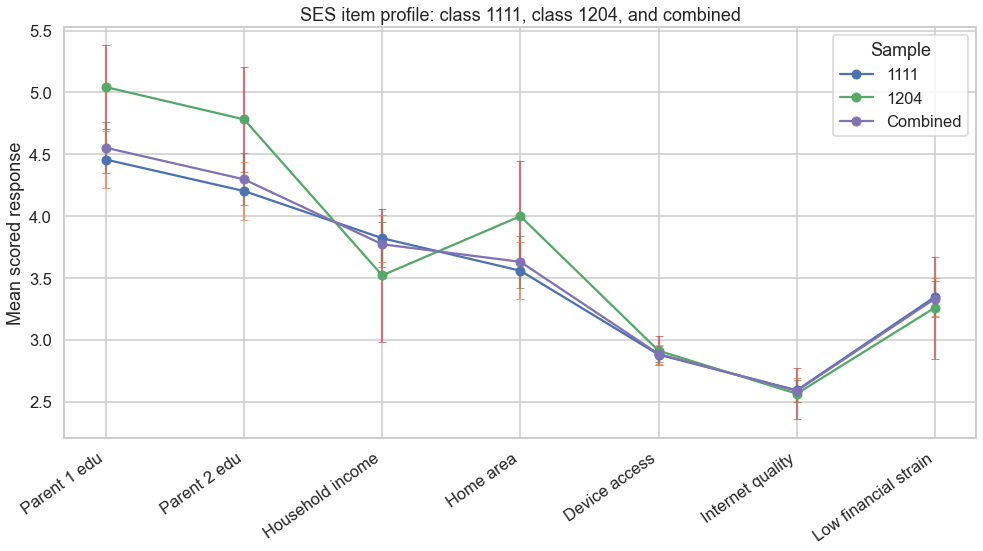

In [37]:
plot_item_profile(df, meta, construct="SES")

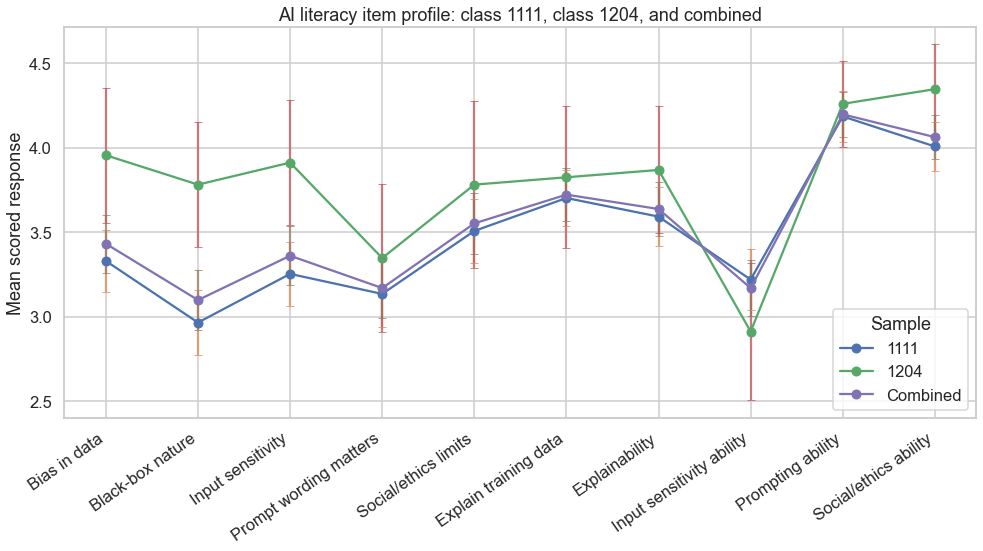

In [38]:
plot_item_profile(df, meta, construct="AI")

### Distribution of composite scores

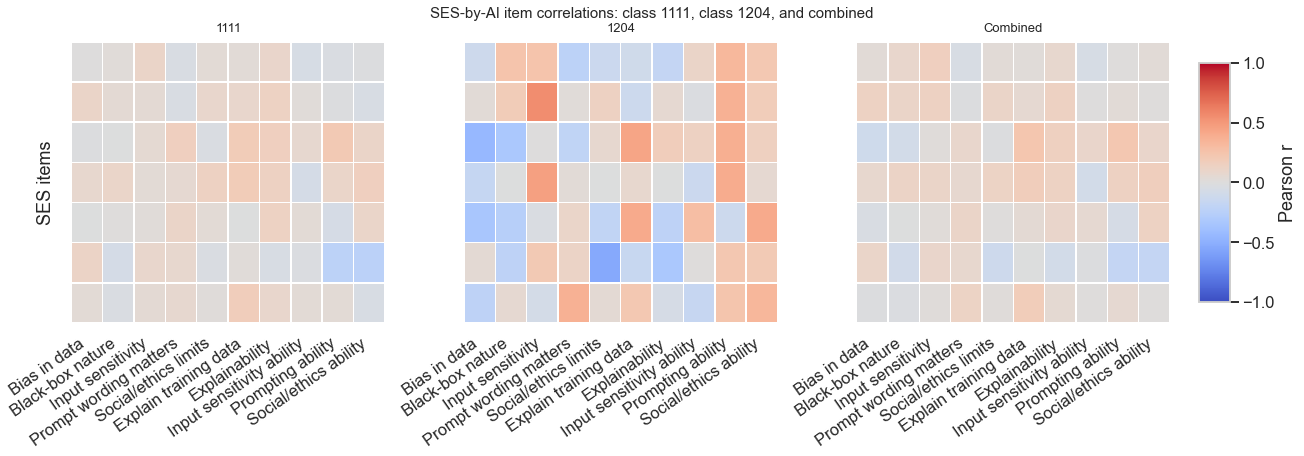

In [39]:
plot_ses_ai_correlation_heatmaps(df, meta)

- In the pooled sample, most correlations are weak to modest, with a tendency
  toward small positive associations rather than a single dominant pattern.
- The 1204 panel shows more extreme values, but given the much smaller
  subgroup size, those correlations are likely less stable.


-----
# SES Effect on AI Literacy (No mediation)

$$\text{AI literacy} = \beta_0 + \beta_1 \text{SES} + \varepsilon$$

In [3]:
run_total_effect_models(df, ses_cols="ses_index", ai_cols="ai_lit_score")

,sample,ses_dimension,ai_outcome,beta_ses_std,p_hc3,ci_low_95,ci_high_95,r_squared,spearman_rho,spearman_p
0,Combined,ses_index,ai_lit_score,0.195893,0.01,0.046838,0.344948,0.038374,0.201231,0.016723


- In the **combined sample**, SES shows a small but statistically supported
  positive association with AI literacy. Students with higher SES tend to
  have slightly higher AI literacy scores.
  
- In **class 1111**, the estimated SES effect is again positive and modest,
  and the result is statistically significant.
- In **class 1204**, the estimated effect is also positive, but highly
  uncertain and not statistically supported — most likely due to the much
  smaller sample size rather than evidence that no relationship exists.

The effect size is not large. In both 1111 and the combined sample, a one
standard deviation increase in SES is associated with only about a 0.2 SD
increase in AI literacy.

The explained variance is low (R² ≈ 0.04), meaning SES accounts for only a
small part of the variation in AI literacy. SES appears to matter, but is
clearly not the only factor.

- The Spearman correlations are also positive in 1111 and in the combined
  sample, supporting the same conclusion from a rank-based perspective.


# Exploratory Factor Analysis (EFA) 

## EFA for AI Literacy

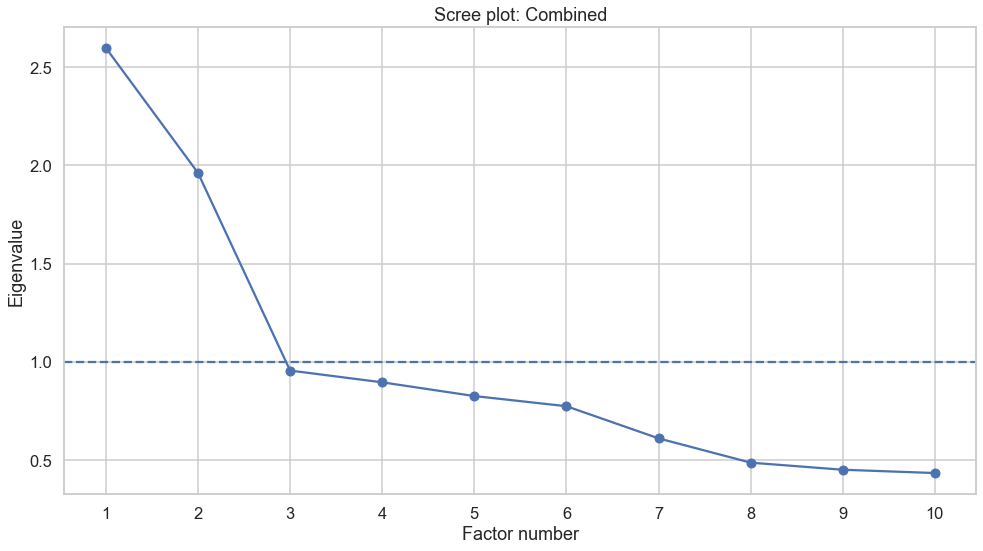

In [3]:
ai_efa_items = [
    "ai_concept_data_bias_scored_num",
    "ai_concept_blackbox_scored_num",
    "ai_concept_input_variation_scored_num",
    "ai_concept_prompt_wording_scored_num",
    "ai_concept_social_ethics_scored_num",
    "ai_ability_training_data_scored_num",
    "ai_ability_explainability_scored_num",
    "ai_ability_input_sensitivity_scored_num",
    "ai_ability_prompting_scored_num",
    "ai_ability_social_ethics_scored_num",
]

df_ai = df.copy()
diag_combined, kmo_items_combined = efa_diagnostics(df_ai, "Combined", ai_efa_items)
eig_combined = run_scree_analysis(df_ai, "Combined", ai_efa_items)
eig_combined

- The eigenvalues support a two-factor modeling. 2 principal components have eigenvalues > 1.

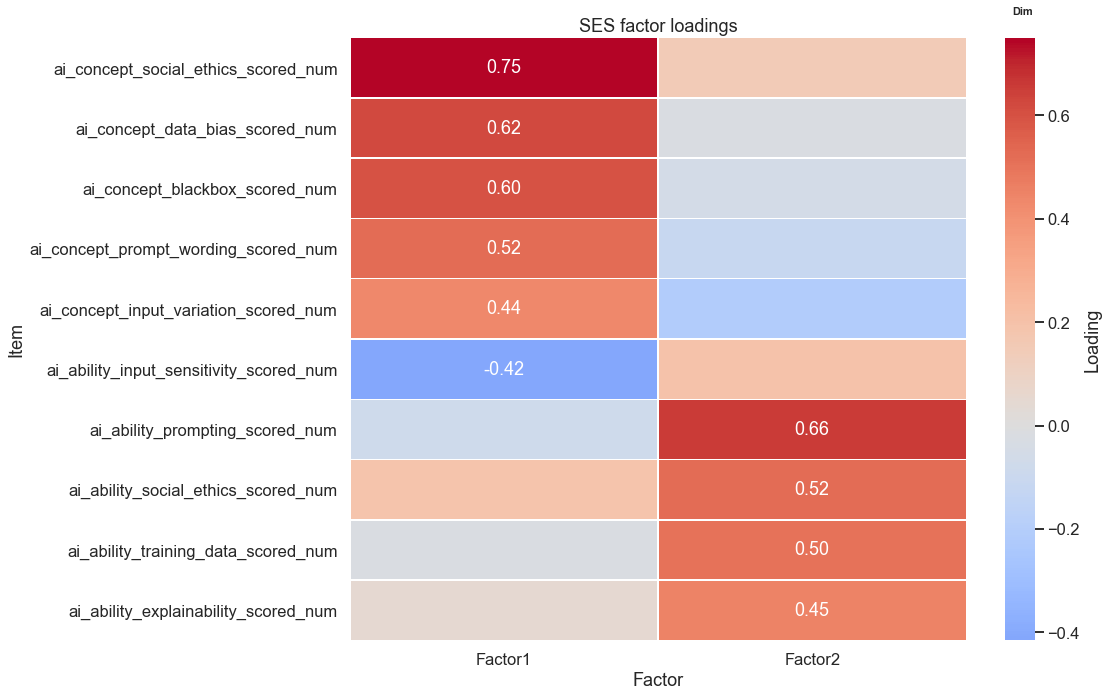

In [4]:
fa_combined, d_combined, loadings_combined, variance_combined = fit_efa(
    df=df_ai,
    sample="Combined",
    items=ai_efa_items,
    n_factors=2,
    rotation="oblimin"
)

plot_loading_heatmap(loadings_combined, cutoff=0.30, title="SES factor loadings")

- *Factor 1 is dominated by the conceptual items*: data bias, black-box nature, input variation, prompt wording, and especially social/ethics limits all load positively on this factor. 

That means Factor 1 can be interpreted as something like conceptual AI understanding

- *Factor 2 is dominated by the self-reported competence items*: explaining training data, explainability, prompting ability, and social/ethics ability load on this factor.

Factor 2 looks like self-reported AI ability/confidence.



## SES variables

### Special test for 'other' school vs non-other school


- Two sided t-test:

$$
H_a: \mu_{\text{other school}} \neq \mu_{\text{non-other school}}
$$

In [5]:
school_others_ses_ttest(df).round(3)

,metric,n_others,mean_diff_others_minus_nonothers,t_stat,p-value,cohens_d
0,Parent 2 education,17,1.066,4.082,0.000,0.866
1,Parent 1 education,17,0.909,3.422,0.002,0.753
2,Home area,17,0.486,1.769,0.090,0.387
3,SES index,17,0.198,1.425,0.169,0.348
4,Device access,17,-0.205,-1.405,0.177,-0.522
5,Low financial strain,17,-0.045,-0.202,0.842,-0.050
6,Household income,17,-0.009,-0.032,0.975,-0.009
7,Internet quality,17,-0.000,-0.003,0.998,-0.001


- Conclusion:

There is no significant difference between 'other school' and 'non-other school' in terms of most SES metrics except Parent education. 

- *Assigns the 'Others school' group to the known group with the smallest Euclidean distance*

Uses the students in the 3 known school groups as reference. Computes the centroid (mean SES profile) for each known group and the centroid for the 'Others school' group. 


### EFA for SES

- new feature: Space_per_person

- quantified school type and housing type

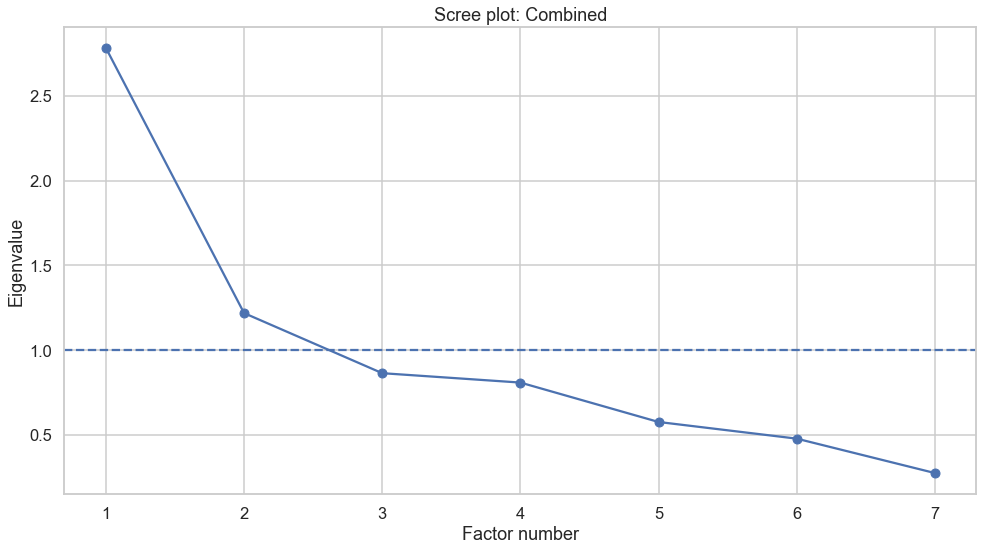

In [6]:
# Language SES is not included here

df_ses = add_ses_space_house_variables(df)

ses_efa_items_2dim = [
    "ses_parent1_edu_num",
    "ses_parent2_edu_num",
    # "ses_device_access_scored_num",
    "ses_household_income_num",
    "ses_financial_constraint_scored_num",
    "ses_space_per_person",
    # "ses_household_size_num",
    "ses_housing_type_ord",
    # "ses_internet_quality_scored_num",
    "ses_school_type_ord",
]

diag_ses_combined, kmo_ses_combined = efa_diagnostics(df_ses, "Combined", ses_efa_items_2dim)
eig_ses_combined = run_scree_analysis(df_ses, "Combined", ses_efa_items_2dim)


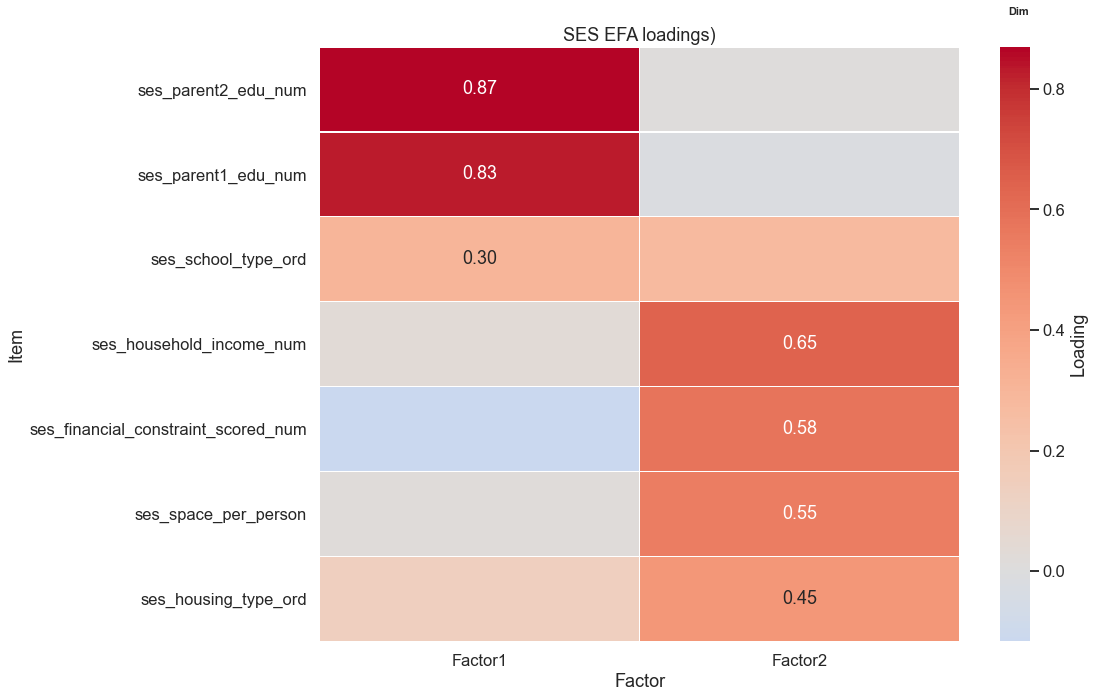

In [10]:
fa_ses2, d_ses2, loadings_ses2, variance_ses2 = fit_efa(
    df=df_ses,
    sample="Combined",
    items=ses_efa_items_2dim,
    n_factors=2,
    rotation="oblimin"
)

plot_loading_heatmap(
    loadings_ses2,
     cutoff=0.3,
    title="SES EFA loadings)"
)

- We may probably try two dimentions in SES

#### Conclusion
- Based on the EFA, SES can be treated as two dimensions:

1. Family / institutional background
	ses_parent1_edu_num 
	ses_parent2_edu_num 
	ses_school_type_ord 

2. Material resources
	ses_household_income_num 
	ses_financial_constraint_scored_num 
	ses_space_per_person 
	ses_housing_type_ord 

AI literacy is better represented by two related but distinct components: 
1. Conceptual understanding 

2. Ability/confidence. 


- Refiting the simple linear model using the factor scores:
It returns a disappointing result: the SES factor is not significantly associated with either AI factor, and the effect sizes are very small. 


------
# Mediator analysis

## Mediator pairs

Each mediator is measured by two different questions. We should check the consistency of these pairs before using them in mediation analyses. 

In [13]:
mediator_reliability = mediator_reliability_table(df, mediator_map)
mediator_reliability

,sample,mediator,n_complete,spearman_rho,alpha_2item
0,1111,conceptual_exposure,118,0.292140,0.486054
1,1111,practical_ai_use,118,0.223236,0.379432
2,1111,learning_ecology,118,0.147209,0.274513
3,1111,language_load,118,0.601679,0.759845
4,1111,epistemic_stance,118,0.320206,0.564601
5,1204,conceptual_exposure,23,0.392293,0.567944
6,1204,practical_ai_use,23,0.367887,0.528373
7,1204,learning_ecology,23,0.399625,0.622269
8,1204,language_load,23,0.625154,0.779258
9,1204,epistemic_stance,23,0.360713,0.406300


- rho >= 0.30 , alpha > 0.5 means acceptable for a 2-item pair 

- Most pairs show at least a modest positive association (by rho and Alpha 2 )

- The weakest pair is learning_ecology (rho ≈ 0.18, p ≈ 0.028). 
This is still positive, but the association is fairly small. That suggests the two items may not be capturing exactly the same thing, even if they belong to the same broad domain.


#### Add composite mediator scores (averaging two items)

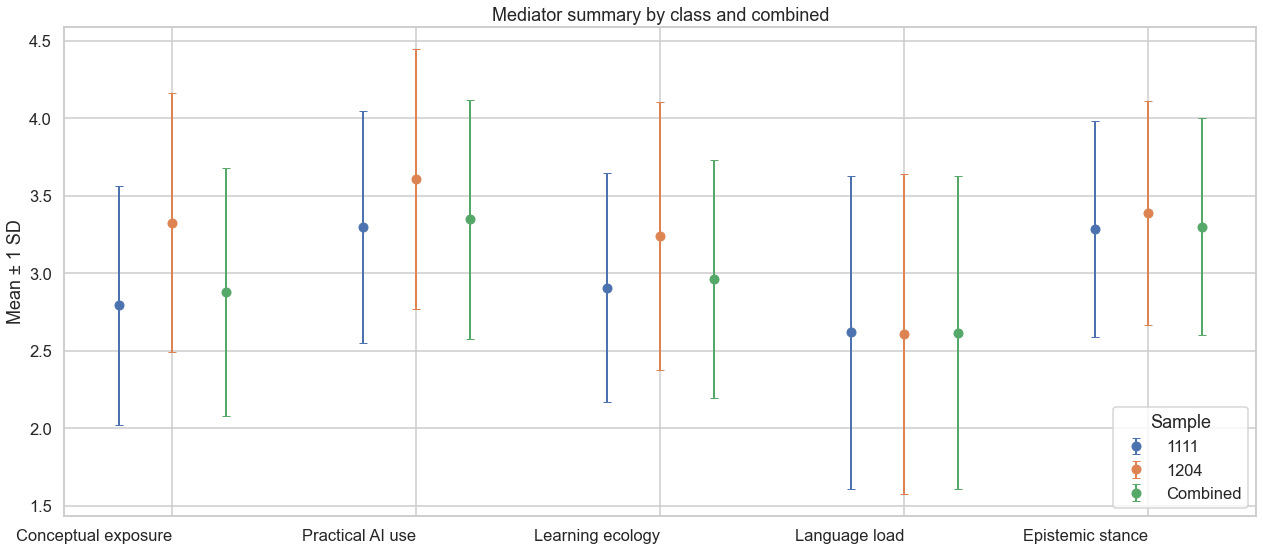

In [14]:
df_med = add_mediator_composites(df, mediator_map)

# mediators table
med_summary = mediator_summary_table(df_med)
plot_mediator_summary(med_summary, errorbar="sd")

## Indirect Effect Model specification
- Mediation models (a path)

$$\text{Mediator} = \alpha_0 + a \cdot SES + \varepsilon_M$$

- Outcome model (b path)

$$\text{AI literacy} = \beta_0 + c' \cdot SES + b \cdot \text{Mediator} + \varepsilon_Y$$

- Indirect effect ($a \cdot b$): greater than zero when a and b are both positive (or both negative)

- Total effect ($c = c' + a \cdot b$)

- Indirect effect coefficient and confidence interval are estimated using bootstrapping

- 2 * SES -> 5* mediators -> 2 * AI factors = 20 mediation models in total


## Direct effect of selected split points of SES on AI literacy

In [23]:
df_analysis = add_ses_ai_factor_scores(
    df_base=df_med,
    ai_df=df,
    ai_items=ai_efa_items,
    ai_fa=fa_combined,
    ses_df=df_ses,
    ses_items=ses_efa_items_2dim,
    ses_fa=fa_ses2
)

mediation_results_2ses = run_all_simple_mediations(
    df_analysis,
    x=["ses_factor1_score", "ses_factor2_score"],
    mediators=mediator_vars,
    outcomes=["ai_factor1_score", "ai_factor2_score"],
    sample_list=["Combined"],
    n_boot=3000,
    seed=2026
)

mediation_results_2ses["ses_dimension"] = mediation_results_2ses["ses_dimension"].map(ses_label_map).fillna(mediation_results_2ses["ses_dimension"])
mediation_results_2ses["outcome"] = mediation_results_2ses["outcome"].map(outcome_label_map).fillna(mediation_results_2ses["outcome"])
mediation_results_2ses["mediator"] = mediation_results_2ses["mediator"].map(mediator_label_map).fillna(mediation_results_2ses["mediator"])
mediation_results_2ses.to_csv("mediation_results_2ses.csv", index=False)

In [20]:
mediation_results_2ses.to_csv("mediation_results_2ses.csv", index=False)

### Multiple testing correction

In [ ]:
mediation_results_2ses["p_fdr"] = multipletests(
    mediation_results_2ses["p_indirect_boot"], method="fdr_bh")[1]

# mediation_results_2ses["p_fdr"] 


,sample,ses_dimension,ai_outcome,beta_ses_std,p_hc3,ci_low_95,ci_high_95,r_squared,spearman_rho,spearman_p
0,Combined,ses_factor2_score,ai_factor1_score,0.060515,0.518543,-0.123204,0.244234,0.003662,0.091949,0.278179


### The indirect-effect forest plot 

- The a path is SES -> Mediator_i

- The b path is the Mediator_i -> AI literacy while controlling for SES.

 Each point is the estimated indirect effect a $\times$ b, and the horizontal line is the bootstrap 95% confidence interval. If the interval stays on one side of zero, that mediator shows clearer evidence of an indirect pathway.

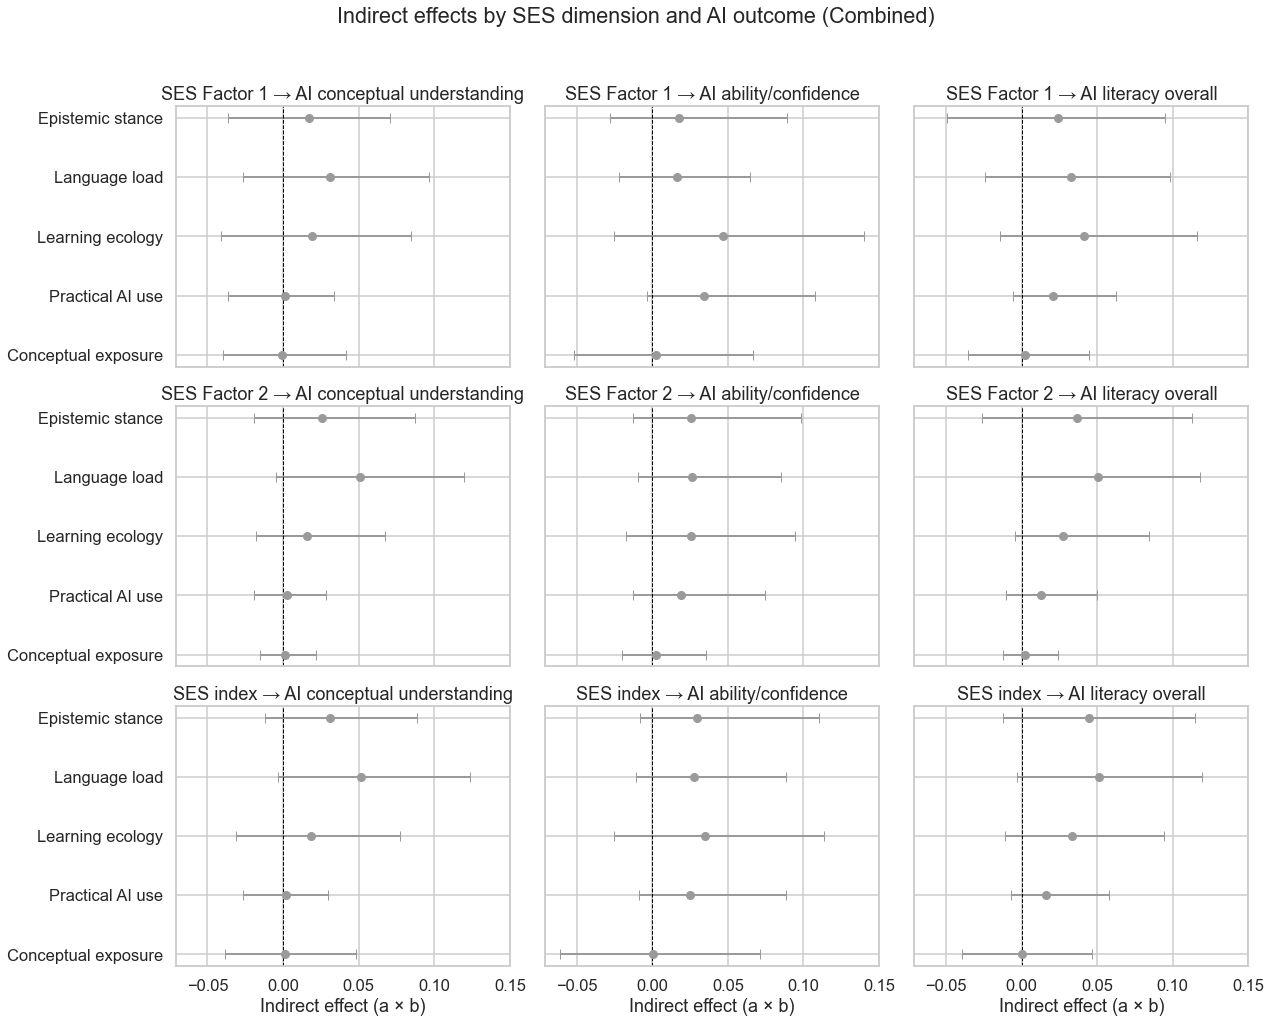

In [134]:
plot_indirect_effect_forest(
    mediation_results_2ses,
    sample="Combined",
    include_ai_overall=True
)

### Summary of results  (No interaction terms):
    
1. Conceptual exposure: The closest pathway was 
    
- material household resources → conceptual exposure → overall AI literacy.
    
    coefficient_beta: 0.003, prop_ab_positive = 0.596

    The indirect effect was extremely small and unstable, so this does not provide meaningful evidence of mediation. In practice, conceptual exposure does not appear to be an important channel linking SES to AI literacy.

2. Practical AI use: The closest pathway was 
    
- family educational capital → practical AI use → AI ability/confidence. 
    
    coefficient_beta: 0.035, prop_ab_positive = 0.946

    Students from stronger educational backgrounds may be somewhat more likely to engage in practical AI use, which may in turn support their AI confidence, but the evidence is still not strong enough to claim a confirmed mediation effect.

3. Learning ecology: The closest pathway:
    
- material household resources → learning ecology → overall AI literacy. 
     
     coefficient_beta: 0.027, prop_ab_positive = 0.936
     
     With stronger material and household resources may have somewhat richer learning environments, which may then support AI literacy. However, the indirect effect still falls short of clear statistical support. 


4. Language load: The closest pathway:

- material household resources → language load → overall AI literacy. 
    
    coefficient_beta: 0.051, prop_ab_positive = 0.974

    Students with better material and household resources may experience lower language burden, and lower language burden may in turn support stronger AI literacy. This is the most promising one.

5. Epistemic stance: The closest pathway: 

- overall SES → epistemic stance → AI ability/confidence. 
    
    coefficient_beta: 0.030, prop_ab_positive = 0.895

    Students with higher SES may develop a somewhat stronger critical stance toward technology, which may then support their confidence in handling AI. However, the evidence remains borderline rather than definitive.


- Overall interpretation: Among the five mediators, language load remains the strongest candidate pathway, with practical AI use, learning ecology, and epistemic stance appearing only as weak secondary candidates. Conceptual exposure does not show a credible mediation role in the current results.


### a–b path plot 

We need both paths to get a meaningful indirect effect, because mediation only exists when SES is linked to the mediator and the mediator is linked to AI literacy.


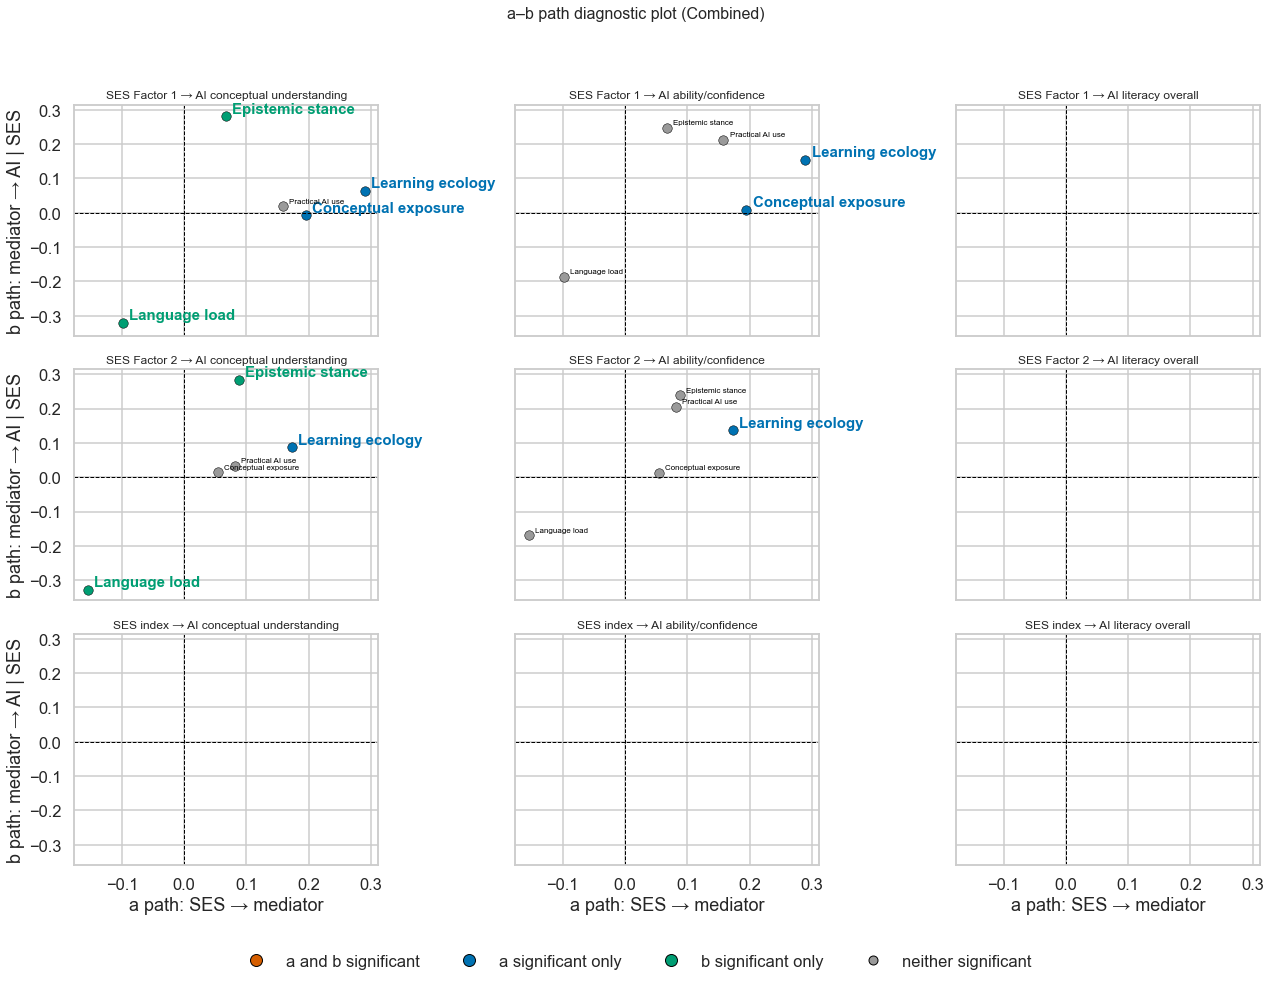

In [26]:
plot_a_b_paths(mediation_results_2ses, sample="Combined")

----- 
## Interaction effects

For two mediators M_1 and M_2, the interaction model you fitted can be written as:
$$
M_{1i} = \alpha_{10} + \alpha_{11} X_i + \varepsilon_{1i}\\

M_{2i} = \alpha_{20} + \alpha_{21} X_i + \varepsilon_{2i}\\

Y_i = \beta_0 + \beta_1 X_i + \beta_2 M_{1i} + \beta_3 M_{2i}
+ \beta_4 (X_i M_{1i}) + \beta_5 (X_i M_{2i}) + \beta_6 (M_{1i} M_{2i}) + \varepsilon_i
$$

where:
- $X_i = SES$
- $M_{1i}, M_{2i}$ = two mediators
- $Y_i$ = AI literacy outcome


## Interaction between Mediators

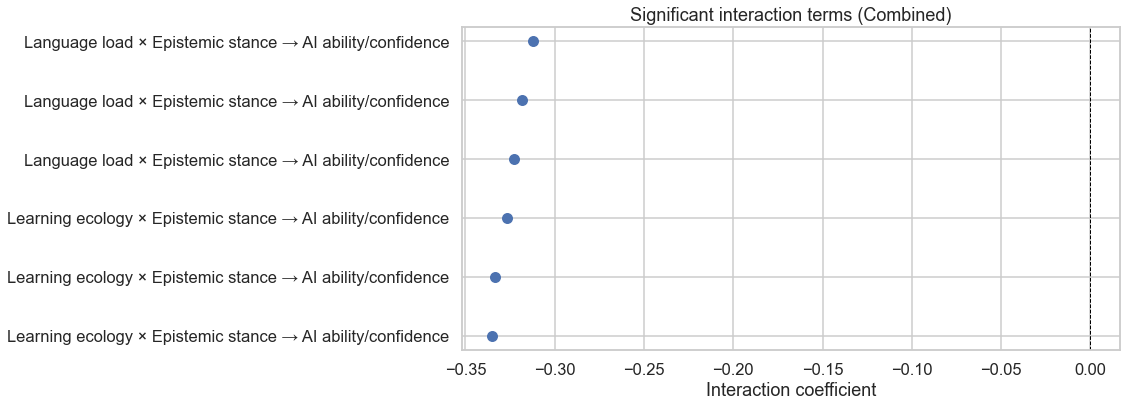

In [174]:
medi_medi_results = run_interaction_mediation_models(
    df_analysis,
    ses_cols=["ses_index", "ses_factor1_score", "ses_factor2_score"],
    mediators=["practical_ai_use_score", "learning_ecology_score", "language_load_score", "epistemic_stance_score"],
    outcomes=["ai_factor1_score", "ai_factor2_score", "ai_lit_score"],
    sample="Combined",
    interaction_type="mediator_mediator"
)

plot_significant_mediator_interactions(
    medi_medi_results,
    alpha=0.05,
    sample="Combined"
)

------
## Interaction between SES and mediators

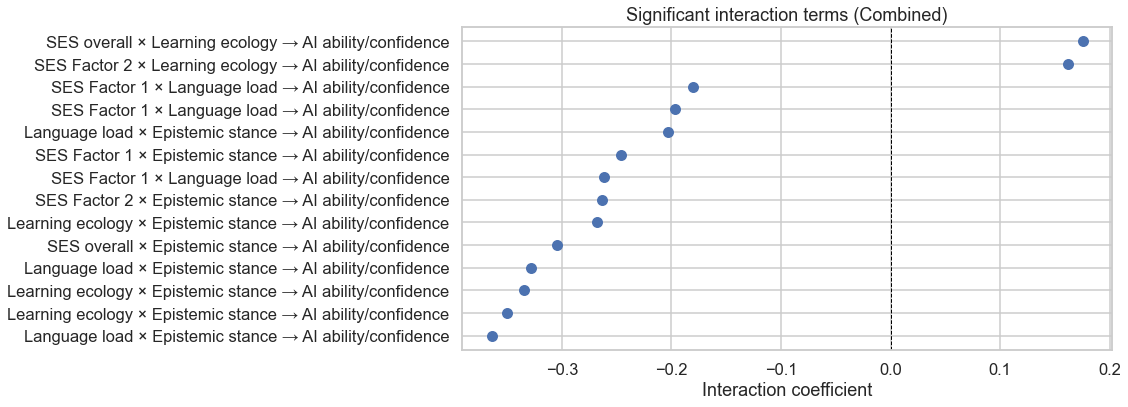

In [175]:
both_results = run_interaction_mediation_models(
    df_analysis,
    ses_cols=["ses_index", "ses_factor1_score", "ses_factor2_score"],
    mediators=["practical_ai_use_score", "learning_ecology_score", "language_load_score", "epistemic_stance_score"],
    outcomes=["ai_factor1_score", "ai_factor2_score", "ai_lit_score"],
    sample="Combined",
    interaction_type="both"
)

summarize_interaction_mediation_results(both_results, interaction_only=True).round(3)

plot_significant_mediator_interactions(
    both_results,
    alpha=0.05,
    sample="Combined"
)

SUMMARY

1. Interaction between Mediators:

1.1. The clearest interaction appears for AI ability/confidence

1.2. Strongest pathway：

    SES → learning ecology × epistemic stance → AI ability/confidence.

- Interpretation:

Across all three SES definitions, the interaction between learning ecology and epistemic stance is negative and significant. If a student already has a very strong learning ecology, having a stronger epistemic stance adds less extra benefit, and vice versa. 


1.3. Secondary pathway:

    SES → language load × epistemic stance → AI ability/confidence.

- Interpretation:

A stronger epistemic stance may help students handle AI better, but that benefit becomes weaker when language burden is high. So even if students are thoughtful and reflective about AI, heavy language difficulty may still limit how confident they feel using it.

2. Interaction between SES and mediators:

2.1. The clearest SES × mediator interaction story is also about AI ability/confidence.

2.2 Learning ecology works better at higher SES

2.3 Epistemic stance and language load tend to matter less at higher SES, especially when SES is split into educational and material dimensions

- Interpretation:

Higher-SES students may rely less on certain personal coping mechanisms, like epistemic stance or managing language burden, because their background already provides support. By contrast, supportive learning ecology seems to become even more beneficial when students also have stronger SES resources.